In [1]:
# Had to run: conda install -c conda-forge cairo pycairo pkg-config in terminal

In [2]:
!python -m pip install daschlab

In [3]:
from daschlab import open_session

sess = open_session("../data/raw/v854_cen_dasch")
sess.select_target("V854 Cen")
sess.select_refcat("apass")

Opened DASCH session at disk location `../data/raw/v854_cen_dasch`
- Query target: `V854 Cen`
- Refcat: 1917 sources from `apass`
- Exposures: 6100 relevant exposures


from erfa import ErfaWarning

 [astropy.utils.exceptions]


In [4]:
exposures = sess.exposures()

In [5]:
exposures
exposures.colnames
exposures[:5]
cutout = sess.cutout(0)
cutout

'cutouts/00000_b03435m0s0.fits'

../data/raw/v854_cen_dasch/cutouts/00000_b03435m0s0.fits
True


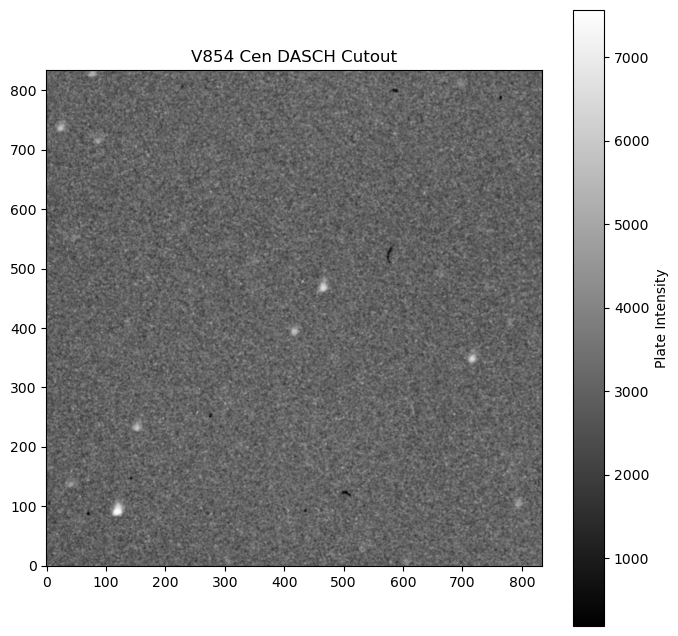

In [6]:
from pathlib import Path
from astropy.io import fits
import matplotlib.pyplot as plt

session_dir = Path("../data/raw/v854_cen_dasch")
cutout_path = session_dir / cutout

print(cutout_path)
print(cutout_path.exists())

data = fits.getdata(cutout_path)

plt.figure(figsize=(8, 8))
plt.imshow(data, origin="lower", cmap="gray")
plt.colorbar(label="Plate Intensity")
plt.title("V854 Cen DASCH Cutout")
plt.show()

In [8]:
from photutils.segmentation import detect_sources, SourceCatalog
from astropy.stats import sigma_clipped_stats
from scipy.ndimage import gaussian_filter
import numpy as np
import matplotlib.pyplot as plt

data_clean = np.array(data, dtype=float)
data_clean[~np.isfinite(data_clean)] = np.nanmedian(data_clean)

# Smooth grain noise
smooth = gaussian_filter(data_clean, sigma=2.0)

mean, median, std = sigma_clipped_stats(smooth, sigma=3.0)

# Detect connected bright regions
segm = detect_sources(
    smooth,
    threshold=median + 4.0 * std,
    npixels=12
)

cat = SourceCatalog(smooth, segm)
sources = cat.to_table()

print("Detected regions:", len(sources))
sources["xcentroid", "ycentroid", "area", "segment_flux"][:20]

Detected regions: 20


xcentroid,ycentroid,area,segment_flux
,,pix2,
float64,float64,float64,float64
605.0958625581363,6.841282768235809,42.0,165866.76893424135
305.2803392598246,7.8326240579034305,18.0,69951.05259665157
529.6426698132329,29.787402058491054,14.0,54230.61781189805
120.1944537355622,94.71741612270624,473.0,2502466.5444228174
793.4116485581267,105.08303326362363,152.0,642493.4869590418
40.52501924444266,137.1643506685865,95.0,392015.54167273105
153.10770220881477,233.99451001624843,229.0,1029667.325151222
716.0312523376336,349.76089721290424,281.0,1306103.353767212


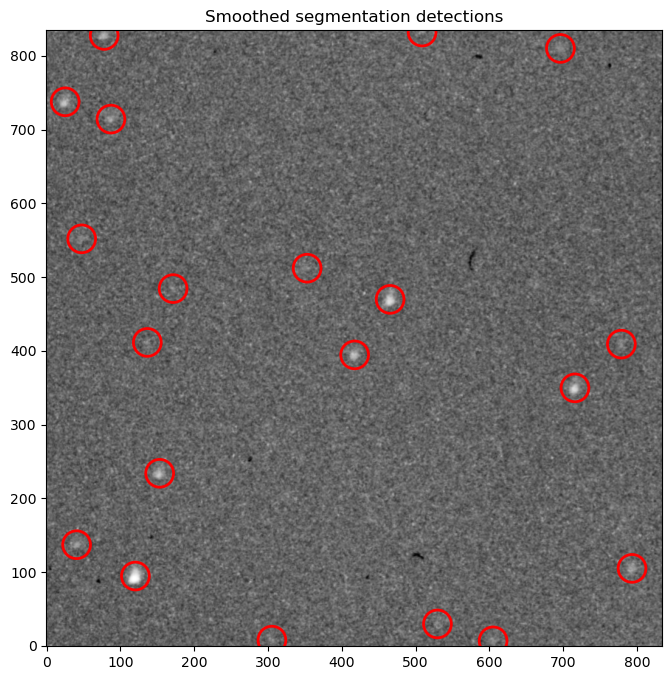

In [9]:
plt.figure(figsize=(8,8))
plt.imshow(data_clean, origin="lower", cmap="gray")

plt.scatter(
    sources["xcentroid"],
    sources["ycentroid"],
    s=400,
    facecolors="none",
    edgecolors="red",
    linewidths=2
)

plt.title("Smoothed segmentation detections")
plt.show()

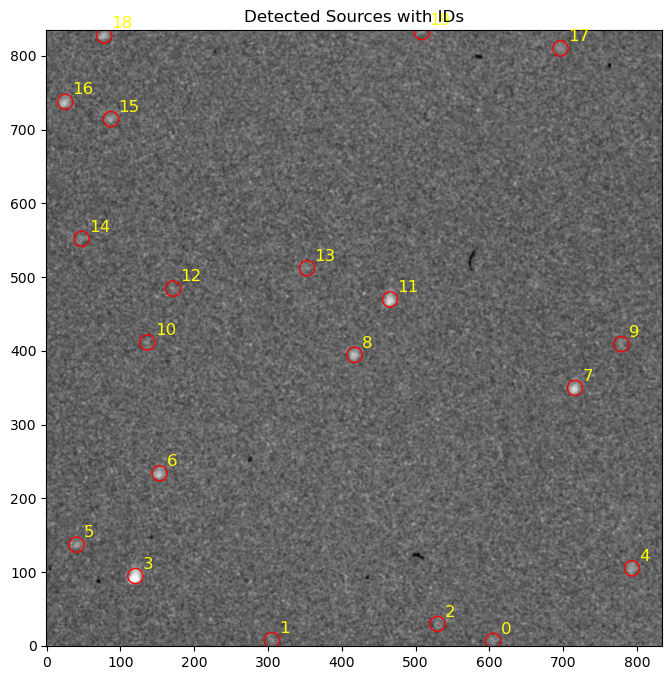

In [10]:
plt.figure(figsize=(8,8))
plt.imshow(data, origin="lower", cmap="gray")

plt.scatter(
    sources["xcentroid"],
    sources["ycentroid"],
    s=120,
    facecolors="none",
    edgecolors="red"
)

for i in range(len(sources)):
    plt.text(
        sources["xcentroid"][i] + 10,
        sources["ycentroid"][i] + 10,
        str(i),
        color="yellow",
        fontsize=12
    )

plt.title("Detected Sources with IDs")
plt.show()

In [21]:
import numpy as np

# Remove edge detections
margin = 30

good = (
    (sources["xcentroid"] > margin) &
    (sources["xcentroid"] < data.shape[1] - margin) &
    (sources["ycentroid"] > margin) &
    (sources["ycentroid"] < data.shape[0] - margin)
)

sources = sources[good]

# Pick correct flux column
if "segment_flux" in sources.colnames:
    flux_col = "segment_flux"
elif "flux" in sources.colnames:
    flux_col = "flux"
else:
    raise ValueError("No usable flux column found.")

# Compute instrumental magnitude
fluxes = np.array(sources[flux_col], dtype=float)

valid_flux = fluxes > 0
sources = sources[valid_flux]
fluxes = fluxes[valid_flux]

sources["inst_mag"] = -2.5 * np.log10(fluxes)

print("Remaining sources:", len(sources))
print("Using flux column:", flux_col)

sources["xcentroid", "ycentroid", flux_col, "inst_mag"]

Remaining sources: 13
Using flux column: segment_flux


xcentroid,ycentroid,segment_flux,inst_mag
float64,float64,float64,float64
120.1944537355622,94.71741612270624,2502466.5444228174,-15.995920700223863
793.4116485581267,105.08303326362363,642493.4869590418,-14.519671823813445
40.52501924444266,137.1643506685865,392015.54167273105,-13.983258213016116
153.10770220881477,233.99451001624843,1029667.325151222,-15.031742328295966
716.0312523376336,349.76089721290424,1306103.353767212,-15.289943861556658
417.39820838124723,394.4620066754532,907294.5244866747,-14.8943707248059
778.9688090315705,409.0548352550321,121013.23640429218,-12.707082189901623
136.38208597049945,411.38122895963926,50625.78647346826,-11.76092945763999
465.489255370115,469.7296996535,1641717.6018413063,-15.538246136359216


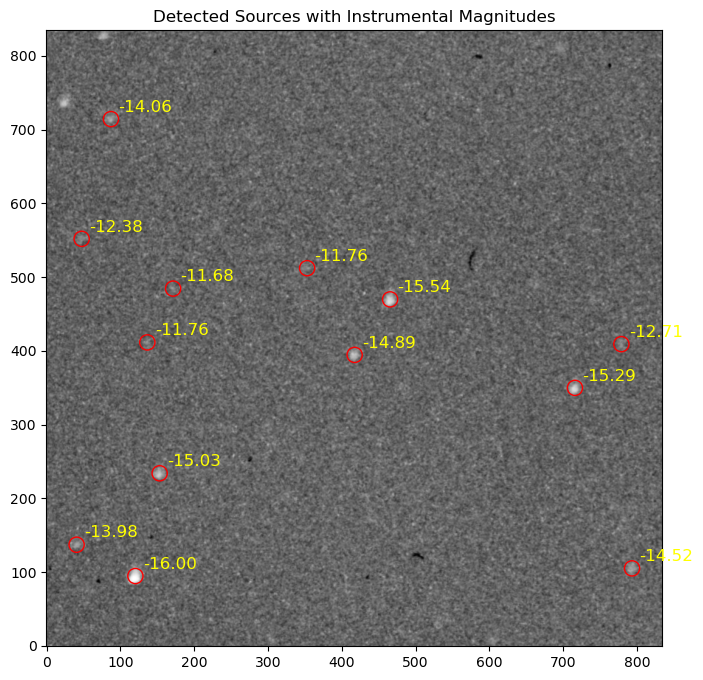

In [22]:
plt.figure(figsize=(8,8))
plt.imshow(data, origin="lower", cmap="gray")

plt.scatter(
    sources["xcentroid"],
    sources["ycentroid"],
    s=120,
    facecolors="none",
    edgecolors="red"
)

for i in range(len(sources)):
    plt.text(
        sources["xcentroid"][i] + 10,
        sources["ycentroid"][i] + 10,
        f'{sources["inst_mag"][i]:.2f}',
        color="yellow",
        fontsize=12
    )

plt.title("Detected Sources with Instrumental Magnitudes")
plt.show()

In [14]:
import os

os.makedirs("../outputs/tables", exist_ok=True)

sources.write(
    "../outputs/tables/segmentation_sources.ecsv",
    overwrite=True
)

print("Saved segmentation_sources.ecsv")

Saved segmentation_sources.ecsv


Sanity Check Report
-------------------
sources_not_none: PASS
enough_sources: PASS
required_columns: PASS
finite_inst_mag: PASS
no_edge_sources: PASS
reasonable_mag_spread: PASS
-------------------
OVERALL: PASS

Source count: 13
Instrumental mag range: -15.995920700223863 to -11.678251217445615


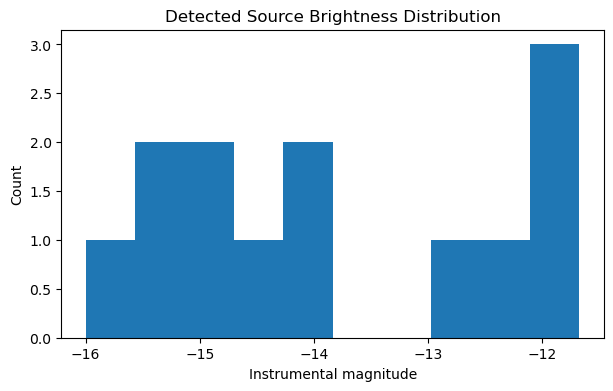

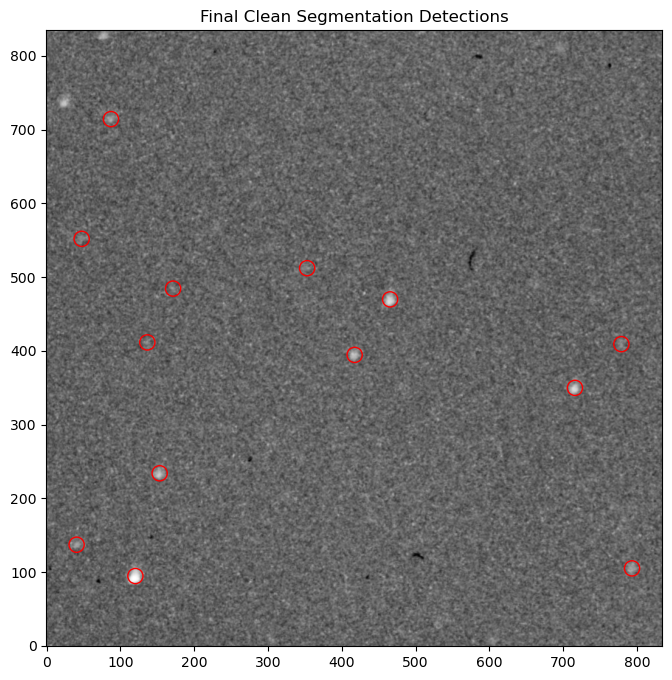

In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt

os.makedirs("../outputs/figures", exist_ok=True)
os.makedirs("../outputs/tables", exist_ok=True)

checks = {}

# Check 1: sources exists
checks["sources_not_none"] = sources is not None

# Check 2: enough sources
checks["enough_sources"] = len(sources) >= 5

# Check 3: required columns exist
required_cols = ["xcentroid", "ycentroid", "inst_mag"]
checks["required_columns"] = all(col in sources.colnames for col in required_cols)

# Check 4: finite magnitudes
checks["finite_inst_mag"] = np.all(np.isfinite(sources["inst_mag"]))

# Check 5: sources not too close to edges
margin = 30
edge_good = (
    (sources["xcentroid"] > margin) &
    (sources["xcentroid"] < data.shape[1] - margin) &
    (sources["ycentroid"] > margin) &
    (sources["ycentroid"] < data.shape[0] - margin)
)
checks["no_edge_sources"] = np.all(edge_good)

# Check 6: reasonable magnitude spread
mag_range = np.max(sources["inst_mag"]) - np.min(sources["inst_mag"])
checks["reasonable_mag_spread"] = mag_range > 0.5

# Print report
print("Sanity Check Report")
print("-------------------")

for name, passed in checks.items():
    print(f"{name}: {'PASS' if passed else 'FAIL'}")

overall = all(checks.values())
print("-------------------")
print("OVERALL:", "PASS" if overall else "FAIL")

print("\nSource count:", len(sources))
print("Instrumental mag range:", np.min(sources["inst_mag"]), "to", np.max(sources["inst_mag"]))

# Save table
sources.write("../outputs/tables/segmentation_sources.ecsv", overwrite=True)

# Plot magnitude histogram
plt.figure(figsize=(7,4))
plt.hist(sources["inst_mag"], bins=10)
plt.xlabel("Instrumental magnitude")
plt.ylabel("Count")
plt.title("Detected Source Brightness Distribution")
plt.savefig("../outputs/figures/inst_mag_histogram.png", dpi=200)
plt.show()

# Plot final detections
plt.figure(figsize=(8,8))
plt.imshow(data, origin="lower", cmap="gray")
plt.scatter(
    sources["xcentroid"],
    sources["ycentroid"],
    s=120,
    facecolors="none",
    edgecolors="red"
)
plt.title("Final Clean Segmentation Detections")
plt.savefig("../outputs/figures/final_segmentation_detections.png", dpi=200)
plt.show()